# AE Checkpoint Evaluation

For each `.ckpt` in `checkpoints/`, computes the relative L2 error on the **physical** field U and displays a histogram.

In [1]:
import sys, os
# Must be set before any CUDA init
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
sys.path.insert(0, os.path.join('..', 'src'))

import glob
import numpy as np
import torch
import torch.nn.functional as F_nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from laplace_surrogate.laplace_transform.forward import laplace_forward_tik
from laplace_surrogate.laplace_transform.inverse import laplace_inverse_tik

## 1. Dataset loading and normalisation

In [2]:
DATA_PATH  = '../dataset/ch4_rotated.npy'
SPLIT_PATH = '../dataset/split.npz'
CKPT_DIR   = '../checkpoints'
CACHE_DIR  = 'cache'          # results cached here to avoid recomputation
N          = 128
DT         = 1.0

os.makedirs(CACHE_DIR, exist_ok=True)

# Raw data (mmap)
U_raw = np.load(DATA_PATH, mmap_mode='r')          # (ns, Nt, H, W)
ns, Nt_full, H, W = U_raw.shape
print(f'Dataset: {ns} sims, Nt={Nt_full}, {H}×{W}')

# Split
split     = np.load(SPLIT_PATH)
test_idx  = split['test_idx'].tolist()
train_idx = [i for i in range(ns) if i not in set(test_idx)]
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}')

Dataset: 8100 sims, Nt=150, 128×128
Train: 6480  Test: 1620


In [3]:
def load_u(idx: int) -> np.ndarray:
    """Load and resize to (Nt, N, N) float32."""
    u = U_raw[idx].astype(np.float32)              # (Nt, H, W)
    if u.shape[-1] != N:
        u_t = torch.from_numpy(u).unsqueeze(1)     # (Nt, 1, H, W)
        u_t = F_nn.interpolate(u_t, size=(N, N), mode='bilinear', align_corners=False)
        u   = u_t.squeeze(1).numpy()
    return u

# Pixel-wise normalisation statistics on the train set
print('Computing U_mean / U_std on train set ...')
U_sum  = np.zeros((N, N), dtype=np.float64)
U_sum2 = np.zeros((N, N), dtype=np.float64)
n_tr   = len(train_idx)
for i in tqdm(train_idx, desc='fit U stats'):
    u = load_u(i)
    U_sum  += u.mean(0).astype(np.float64)
    U_sum2 += (u ** 2).mean(0).astype(np.float64)

U_mean = (U_sum  / n_tr).astype(np.float32)         # (N, N)
U_std  = np.sqrt(np.maximum(U_sum2 / n_tr - U_mean ** 2, 0)).astype(np.float32)
U_std  = np.where(U_std < 1e-8, 1.0, U_std)
print('Done.')

Computing U_mean / U_std on train set ...


fit U stats:   0%|          | 0/6480 [00:00<?, ?it/s]

Done.


## 2. Evaluation functions

In [4]:
import gc

def _strip_model_prefix(state_dict):
    """Remove the 'model.' prefix added by Lightning."""
    return {k[len('model.'):]: v for k, v in state_dict.items() if k.startswith('model.')}


ALPHA_T_SLAE = 0.007
LAM_SLAE     = 3e-5

# -------------------------------------------------------------------------
# SLAE  —  full GPU pipeline (Laplace in float32 on device)
# -------------------------------------------------------------------------
def eval_slae(ckpt_path: str, idx_list: list, device='cpu') -> np.ndarray:
    ckpt      = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg_model = ckpt['hyper_parameters']['cfg']['model']
    s_list_np = ckpt['s_list']
    K         = len(s_list_np)
    dt        = float(ckpt.get('dt', DT))

    from laplace_surrogate.models.slae import SLAE
    model = SLAE(N=N, latent_dim=ckpt['latent_dim'],
                 beta=cfg_model.get('beta', 0.01),
                 freq_L=cfg_model.get('freq_L', 8))
    model.load_state_dict(_strip_model_prefix(ckpt['state_dict']))
    model.eval().to(device)

    # complex64 on device → Laplace runs fully on GPU
    s_tensor   = torch.tensor(s_list_np, dtype=torch.complex128)   # float64 CPU
    lap_mean_t = torch.tensor(ckpt['lap_mean'], dtype=torch.float32, device=device)
    lap_std_t  = torch.tensor(ckpt['lap_std'],  dtype=torch.float32, device=device)
    fr_t       = torch.tensor(np.arange(K, dtype=np.float32) / max(K - 1, 1), device=device)

    l2rel_list = []
    with torch.no_grad():
        for i, idx in enumerate(tqdm(idx_list, desc=os.path.basename(ckpt_path), leave=False)):
            U_phys = load_u(idx)
            Nt     = U_phys.shape[0]

            # Laplace forward — float32 on GPU
            u_flat = torch.tensor(U_phys.reshape(Nt, N * N).T, dtype=torch.float64)
            U_lap    = laplace_forward_tik(u_flat, s_tensor, dt, 'trap')  # (N², K) complex64
            U_lap_np = U_lap.numpy().reshape(N, N, K)
            del u_flat, U_lap

            u_batch  = np.stack([np.stack([U_lap_np[:, :, k].real,
                                            U_lap_np[:, :, k].imag], axis=0)
                                  for k in range(K)]).astype(np.float32)
            del U_lap_np

            u_b_t    = torch.tensor(u_batch, device=device)
            u_b_norm = (u_b_t - lap_mean_t) / lap_std_t
            del u_b_t, u_batch

            u_rec_norm, _ = model(u_b_norm, fr_t)
            del u_b_norm
            u_rec_np = (u_rec_norm * lap_std_t + lap_mean_t).cpu().numpy()
            del u_rec_norm

            # Laplace inverse — float32 on GPU
            U_lap_rec = (u_rec_np[:, 0] + 1j * u_rec_np[:, 1]).transpose(1, 2, 0)
            del u_rec_np
            U_lap_rec_flat = torch.tensor(U_lap_rec.reshape(N * N, K), dtype=torch.complex128)
            del U_lap_rec

            U_rec_flat = laplace_inverse_tik(U_lap_rec_flat, s_tensor, dt, Nt,
                                             alpha_t=ALPHA_T_SLAE, lam=LAM_SLAE)
            del U_lap_rec_flat
            U_rec = U_rec_flat.numpy().T.reshape(Nt, N, N).astype(np.float32)
            del U_rec_flat

            denom = np.linalg.norm(U_phys)
            if denom >= 1e-12:
                l2rel_list.append(np.linalg.norm(U_rec - U_phys) / denom * 100.0)
            del U_rec

            if device == 'cuda' and i % 50 == 0:
                torch.cuda.empty_cache()

    model.cpu()
    del model
    if device == 'cuda': torch.cuda.empty_cache()
    gc.collect()
    return np.array(l2rel_list)


# -------------------------------------------------------------------------
# LLAE  —  full GPU pipeline (Laplace in latent space via LearnableLaplace)
# -------------------------------------------------------------------------
def eval_llae(ckpt_path: str, idx_list: list, device='cpu') -> np.ndarray:
    ckpt      = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg_model = ckpt['hyper_parameters']['cfg']['model']

    from laplace_surrogate.models.llae import LLAE
    model = LLAE(
        N=ckpt['N'], Nt=cfg_model.get('Nt', 150),
        latent_dim=ckpt['latent_dim'], K=cfg_model['K'],
        dt=float(ckpt.get('dt', DT)),
        beta=cfg_model.get('beta', 0.01),
        beta_latent=cfg_model.get('beta_latent', 0.1),
        gamma_init=cfg_model.get('gamma_init', 0.01),
        time_L=cfg_model.get('time_L', 8),
        learnable_laplace=cfg_model.get('learnable_laplace', False),
        alpha_t=cfg_model.get('alpha_t', 0.007),
        lam=cfg_model.get('lam', 3e-5),
    )
    model.load_state_dict(_strip_model_prefix(ckpt['state_dict']))
    model.eval().to(device)

    l2rel_list = []
    with torch.no_grad():
        for idx in tqdm(idx_list, desc=os.path.basename(ckpt_path), leave=False):
            U_phys = load_u(idx)
            U_t    = torch.tensor((U_phys - U_mean) / U_std, dtype=torch.float32,
                                   device=device)[None]
            U_rec_n, _, _, _ = model(U_t)
            U_rec = U_rec_n.squeeze(0).cpu().numpy() * U_std + U_mean
            del U_t, U_rec_n

            denom = np.linalg.norm(U_phys)
            if denom >= 1e-12:
                l2rel_list.append(np.linalg.norm(U_rec - U_phys) / denom * 100.0)

    model.cpu()
    del model
    if device == 'cuda': torch.cuda.empty_cache()
    gc.collect()
    return np.array(l2rel_list)

In [5]:
# float32 vs float64 precision test for the Laplace transform in physical space.
# If L2rel(f32) ≈ L2rel(f64), the Laplace can be moved to GPU (float32).

K_diag   = 16
gamma_d  = 0.0
dt_d     = 1.0
s_im_d   = 2 * np.pi * np.fft.fftfreq(150, d=1.0)[:K_diag]
s_list_d = (gamma_d + 1j * s_im_d).astype(np.complex128)

s64 = torch.tensor(s_list_d, dtype=torch.complex128)   # CPU float64
s32 = torch.tensor(s_list_d, dtype=torch.complex64)    # CPU float32

n_diag   = 200
diag_idx = test_idx[:n_diag]

l2_f64, l2_f32, l2_diff = [], [], []

with torch.no_grad():
    for idx in tqdm(diag_idx, desc='f32 vs f64 Laplace'):
        U_phys = load_u(idx)
        Nt     = U_phys.shape[0]
        U_norm = (U_phys - U_mean) / U_std

        # ── float64 (reference) ─────────────────────────────────────────
        u64 = torch.tensor(U_norm.reshape(Nt, N * N).T, dtype=torch.float64)
        from laplace_surrogate.laplace_transform.inverse import laplace_inverse_tik
        U_lap64    = laplace_forward_tik(u64, s64, dt_d, 'trap')
        U_rec64_flat = laplace_inverse_tik(U_lap64, s64, dt_d, Nt,
                                           alpha_t=ALPHA_T_SLAE, lam=LAM_SLAE)
        U_rec64 = (U_rec64_flat.numpy().T.reshape(Nt, N, N).astype(np.float32)
                   * U_std + U_mean)

        # ── float32 (GPU-compatible) ─────────────────────────────────────
        u32 = torch.tensor(U_norm.reshape(Nt, N * N).T, dtype=torch.float32)
        U_lap32    = laplace_forward_tik(u32.to(torch.float32), s32, dt_d, 'trap')
        U_rec32_flat = laplace_inverse_tik(U_lap32, s32, dt_d, Nt,
                                           alpha_t=ALPHA_T_SLAE, lam=LAM_SLAE)
        U_rec32 = (U_rec32_flat.real.numpy().T.reshape(Nt, N, N).astype(np.float32)
                   * U_std + U_mean)

        denom = np.linalg.norm(U_phys)
        if denom > 1e-12:
            l2_f64.append(np.linalg.norm(U_rec64 - U_phys) / denom * 100.0)
            l2_f32.append(np.linalg.norm(U_rec32 - U_phys) / denom * 100.0)
            # difference between f32 and f64 reconstructions
            l2_diff.append(np.linalg.norm(U_rec32 - U_rec64) / denom * 100.0)

l2_f64  = np.array(l2_f64)
l2_f32  = np.array(l2_f32)
l2_diff = np.array(l2_diff)

print(f"{'':30s}  {'median':>8}  {'mean':>8}  {'p90':>8}")
print('-' * 58)
print(f"{'float64 (reference)':<30}  {np.median(l2_f64):>7.2f}%  {np.mean(l2_f64):>7.2f}%  {np.percentile(l2_f64,90):>7.2f}%")
print(f"{'float32 (GPU-ready)':<30}  {np.median(l2_f32):>7.2f}%  {np.mean(l2_f32):>7.2f}%  {np.percentile(l2_f32,90):>7.2f}%")
print(f"{'|f32 - f64| (rounding error)':<30}  {np.median(l2_diff):>7.4f}%  {np.mean(l2_diff):>7.4f}%  {np.percentile(l2_diff,90):>7.4f}%")
print()
if np.median(l2_diff) < 0.01 * np.median(l2_f64):
    print("→ float32 rounding error < 1% of truncation error: Laplace can safely move to GPU.")
else:
    print("→ float32 rounding error is significant: float64 required.")

f32 vs f64 Laplace:   0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 3. Evaluation of all checkpoints

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

ckpt_paths = sorted(glob.glob(os.path.join(CKPT_DIR, '*.ckpt')))
print(f'{len(ckpt_paths)} checkpoints found:')
for p in ckpt_paths:
    print(' ', os.path.basename(p))

Device: cuda
14 checkpoints found:
  llae_ld128_K16_g0.01.ckpt
  llae_ld32_K16_g0.01.ckpt
  llae_ld64_K16_g0.0.ckpt
  llae_ld64_K16_g0.001.ckpt
  llae_ld64_K16_g0.01.ckpt
  llae_ld64_K32_g0.01.ckpt
  llae_ld64_K8_g0.01.ckpt
  slae_ld128_K16_g0.01.ckpt
  slae_ld32_K16_g0.01.ckpt
  slae_ld64_K16_g0.0.ckpt
  slae_ld64_K16_g0.001.ckpt
  slae_ld64_K16_g0.01.ckpt
  slae_ld64_K32_g0.01.ckpt
  slae_ld64_K8_g0.01.ckpt


In [7]:
def _cache_path(name: str) -> str:
    return os.path.join(CACHE_DIR, f'{name}.npz')

def _cache_valid(cache_file: str, ckpt_path: str) -> bool:
    """Check that the cache exists and matches the current checkpoint (via mtime)."""
    if not os.path.exists(cache_file):
        return False
    data = np.load(cache_file, allow_pickle=True)
    return float(data['ckpt_mtime']) == os.path.getmtime(ckpt_path)

def _save_cache(name: str, ckpt_path: str, l2rel: np.ndarray):
    np.savez(
        _cache_path(name),
        l2rel      = l2rel,
        ckpt_mtime = np.float64(os.path.getmtime(ckpt_path)),
    )

def _load_cache(name: str) -> np.ndarray:
    return np.load(_cache_path(name))['l2rel']


# ── Main loop ───────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}\n')

ckpt_paths = sorted(glob.glob(os.path.join(CKPT_DIR, '*.ckpt')))
print(f'{len(ckpt_paths)} checkpoints:\n')

results = {}   # name → np.array of L2rel (%)

for ckpt_path in ckpt_paths:
    name       = os.path.splitext(os.path.basename(ckpt_path))[0]
    model_type = 'llae' if name.startswith('llae') else 'slae'
    cache_file = _cache_path(name)

    if _cache_valid(cache_file, ckpt_path):
        l2 = _load_cache(name)
        print(f'[cache] {name}')
    else:
        print(f'[compute] {name}  [{model_type}]')
        try:
            if model_type == 'slae':
                l2 = eval_slae(ckpt_path, test_idx, device=device)
            else:
                l2 = eval_llae(ckpt_path, test_idx, device=device)
            _save_cache(name, ckpt_path, l2)
        except Exception as e:
            print(f'   ERROR: {e}')
            continue

    results[name] = l2
    print(f'   median={np.median(l2):.2f}%  mean={np.mean(l2):.2f}%  p90={np.percentile(l2,90):.2f}%  n={len(l2)}')

print('\nDone.')

Device: cuda

14 checkpoints:

[compute] llae_ld128_K16_g0.01  [llae]


llae_ld128_K16_g0.01.ckpt:   0%|          | 0/1620 [00:00<?, ?it/s]

   median=2.92%  mean=3.15%  p90=4.38%  n=1620
[cache] llae_ld32_K16_g0.01
   median=3.43%  mean=3.85%  p90=5.60%  n=1620
[compute] llae_ld64_K16_g0.0  [llae]


llae_ld64_K16_g0.0.ckpt:   0%|          | 0/1620 [00:00<?, ?it/s]

   median=3.26%  mean=3.61%  p90=5.24%  n=1620
[cache] llae_ld64_K16_g0.001
   median=3.32%  mean=3.65%  p90=5.16%  n=1620
[compute] llae_ld64_K16_g0.01  [llae]


llae_ld64_K16_g0.01.ckpt:   0%|          | 0/1620 [00:00<?, ?it/s]

   median=3.20%  mean=3.47%  p90=5.04%  n=1620
[cache] llae_ld64_K32_g0.01
   median=3.19%  mean=3.53%  p90=5.11%  n=1620
[cache] llae_ld64_K8_g0.01
   median=3.35%  mean=3.66%  p90=5.26%  n=1620
[cache] slae_ld128_K16_g0.01
   median=7.98%  mean=8.40%  p90=10.45%  n=1620
[cache] slae_ld32_K16_g0.01
   median=10.76%  mean=11.14%  p90=14.76%  n=1620
[cache] slae_ld64_K16_g0.0
   median=7.78%  mean=8.11%  p90=9.91%  n=1620
[cache] slae_ld64_K16_g0.001
   median=7.82%  mean=8.27%  p90=10.36%  n=1620
[cache] slae_ld64_K16_g0.01
   median=8.92%  mean=9.53%  p90=12.55%  n=1620
[cache] slae_ld64_K32_g0.01
   median=8.34%  mean=9.27%  p90=13.43%  n=1620
[cache] slae_ld64_K8_g0.01
   median=12.26%  mean=12.74%  p90=15.40%  n=1620

Done.


## 4. Histograms per checkpoint

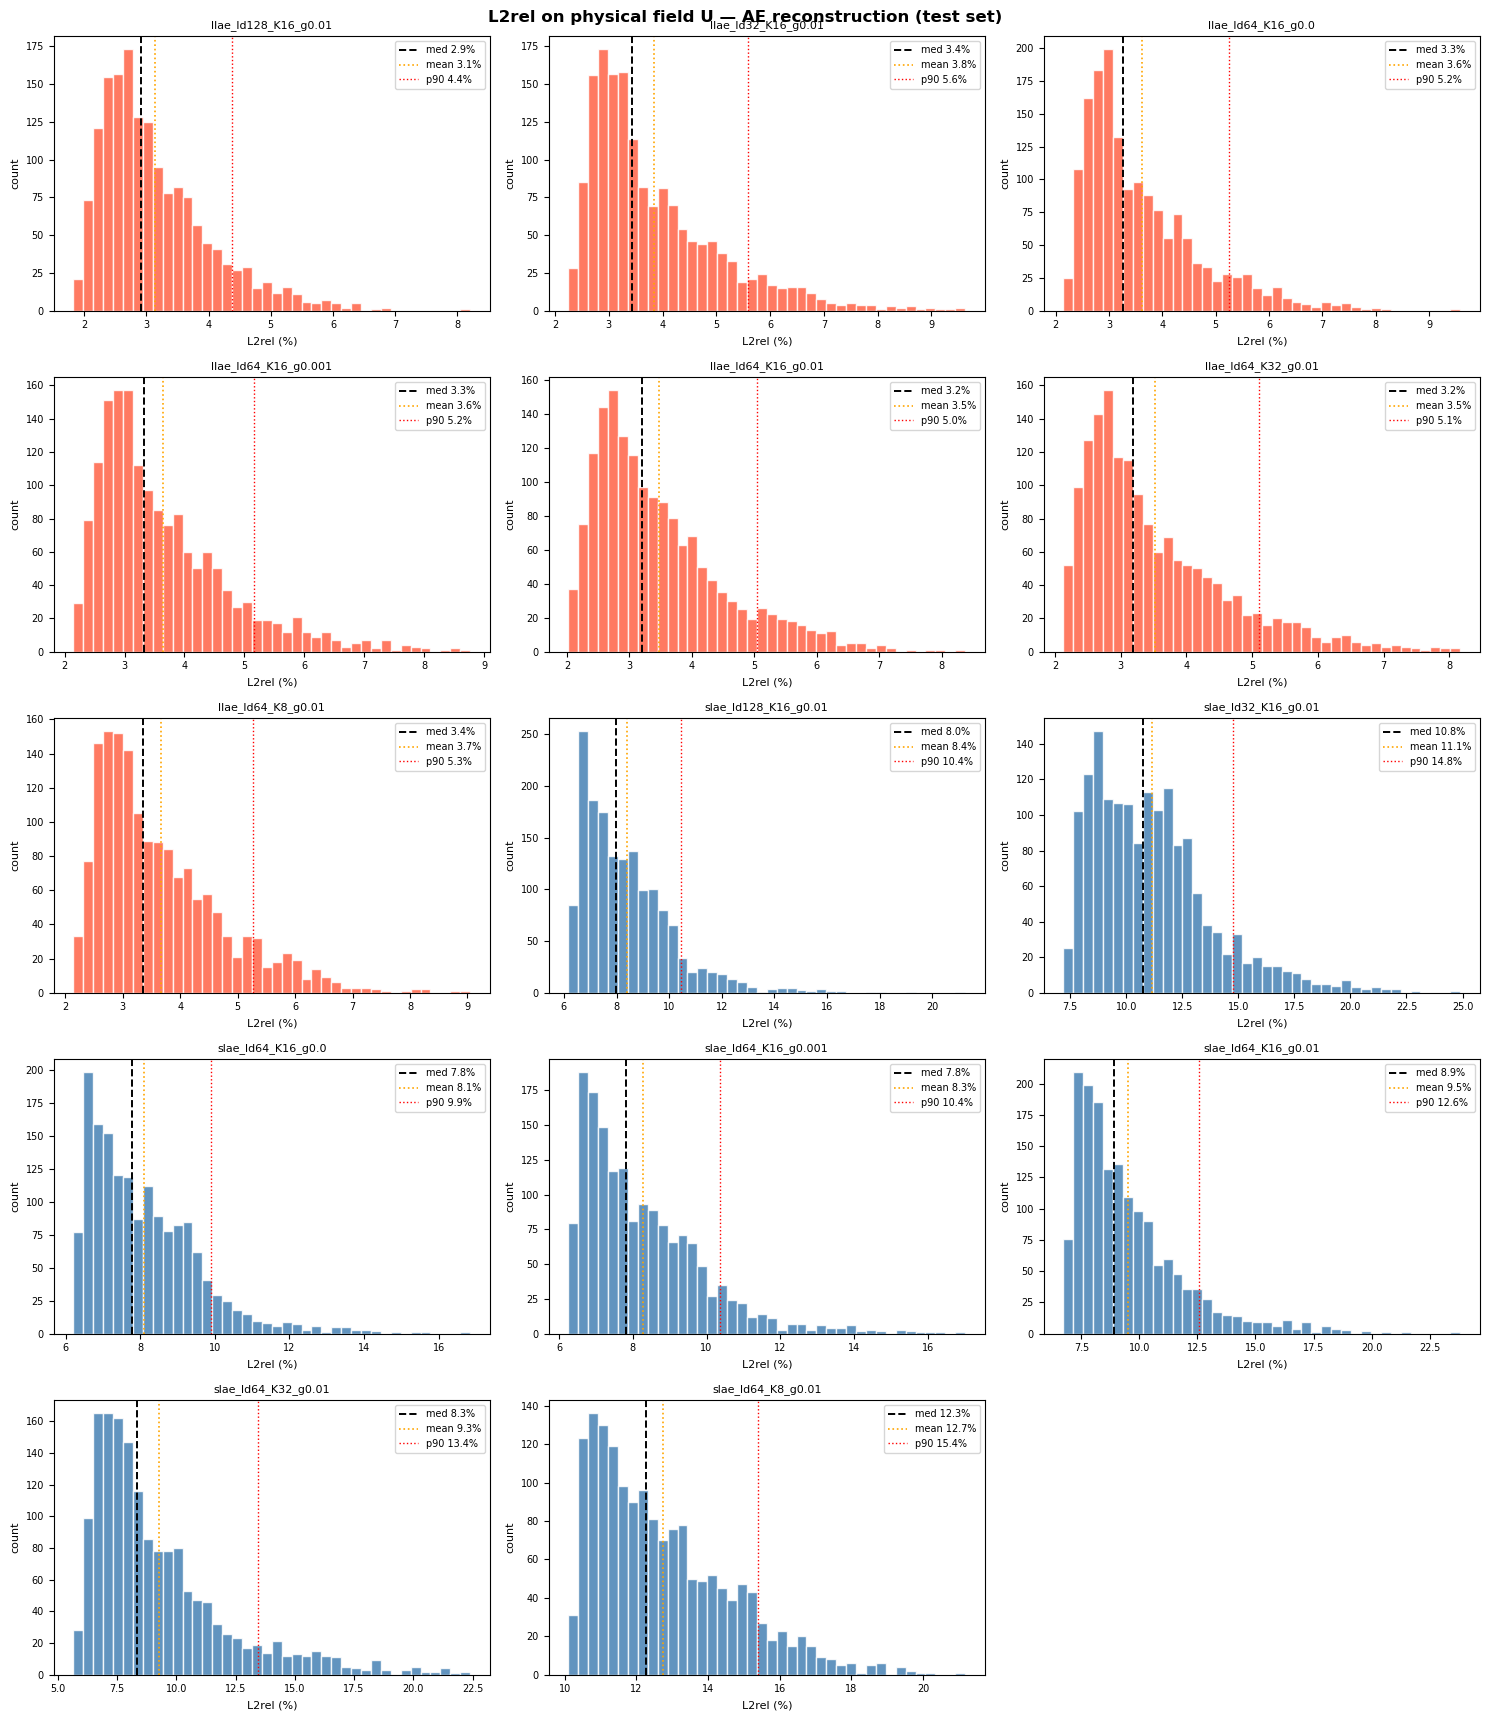

In [8]:
names  = list(results.keys())
n_ckpt = len(names)
ncols  = 3
nrows  = (n_ckpt + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

colors = {'slae': 'steelblue', 'llae': 'tomato'}

for ax, name in zip(axes, names):
    l2      = results[name]
    mtype   = 'llae' if name.startswith('llae') else 'slae'
    median  = np.median(l2)
    mean    = np.mean(l2)
    p90     = np.percentile(l2, 90)

    ax.hist(l2, bins=40, color=colors[mtype], edgecolor='white', alpha=0.85)
    ax.axvline(median, color='black',  linestyle='--', linewidth=1.4, label=f'med {median:.1f}%')
    ax.axvline(mean,   color='orange', linestyle=':',  linewidth=1.2, label=f'mean {mean:.1f}%')
    ax.axvline(p90,    color='red',    linestyle=':',  linewidth=1.0, label=f'p90 {p90:.1f}%')
    ax.set_title(name, fontsize=8)
    ax.set_xlabel('L2rel (%)', fontsize=8)
    ax.set_ylabel('count', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

for ax in axes[n_ckpt:]:
    ax.set_visible(False)

fig.suptitle('L2rel on physical field U — AE reconstruction (test set)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

## 5. Median comparison

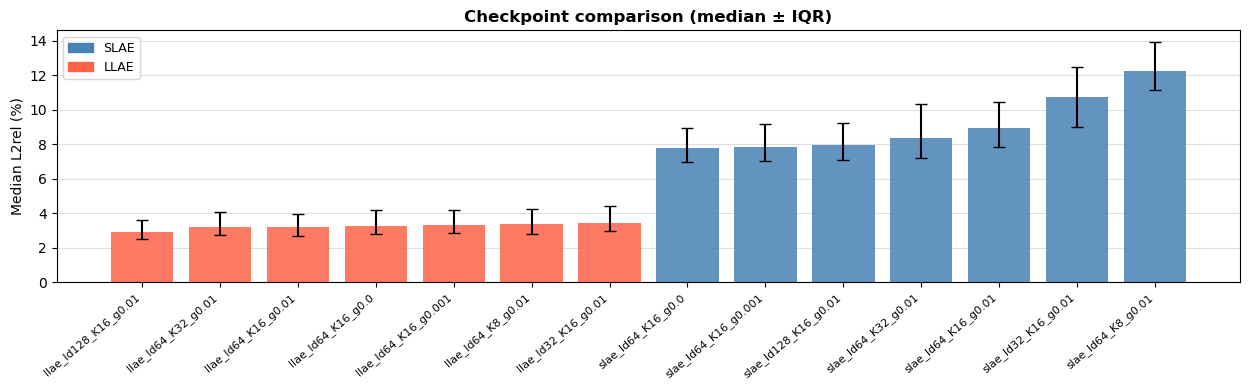

In [9]:
medians = {n: float(np.median(v)) for n, v in results.items()}
p25     = {n: float(np.percentile(v, 25)) for n, v in results.items()}
p75     = {n: float(np.percentile(v, 75)) for n, v in results.items()}

sorted_names = sorted(medians, key=lambda n: medians[n])
bar_colors   = [colors['llae' if n.startswith('llae') else 'slae'] for n in sorted_names]

fig, ax = plt.subplots(figsize=(max(8, n_ckpt * 0.9), 4))
x = np.arange(len(sorted_names))

bars = ax.bar(x, [medians[n] for n in sorted_names], color=bar_colors, alpha=0.85, zorder=2)

# IQR error bars
yerr_low  = [medians[n] - p25[n] for n in sorted_names]
yerr_high = [p75[n] - medians[n] for n in sorted_names]
ax.errorbar(x, [medians[n] for n in sorted_names],
            yerr=[yerr_low, yerr_high],
            fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(sorted_names, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Median L2rel (%)')
ax.set_title('Checkpoint comparison (median ± IQR)', fontweight='bold')
ax.grid(axis='y', alpha=0.4, zorder=0)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue', label='SLAE'),
    Patch(color='tomato',    label='LLAE'),
], fontsize=9)

fig.tight_layout()
plt.show()

## 6. Summary 

In [10]:
print(f"{'Checkpoint':<40}  {'type':^5}  {'median':>8}  {'mean':>8}  {'p90':>8}  {'n':>5}")
print('-' * 82)
for n in sorted(results, key=lambda n: np.median(results[n])):
    l2    = results[n]
    mtype = 'llae' if n.startswith('llae') else 'slae'
    print(f'{n:<40}  {mtype:^5}  {np.median(l2):>7.2f}%  {np.mean(l2):>7.2f}%  {np.percentile(l2,90):>7.2f}%  {len(l2):>5}')

Checkpoint                                type     median      mean       p90      n
----------------------------------------------------------------------------------
llae_ld128_K16_g0.01                      llae      2.92%     3.15%     4.38%   1620
llae_ld64_K32_g0.01                       llae      3.19%     3.53%     5.11%   1620
llae_ld64_K16_g0.01                       llae      3.20%     3.47%     5.04%   1620
llae_ld64_K16_g0.0                        llae      3.26%     3.61%     5.24%   1620
llae_ld64_K16_g0.001                      llae      3.32%     3.65%     5.16%   1620
llae_ld64_K8_g0.01                        llae      3.35%     3.66%     5.26%   1620
llae_ld32_K16_g0.01                       llae      3.43%     3.85%     5.60%   1620
slae_ld64_K16_g0.0                        slae      7.78%     8.11%     9.91%   1620
slae_ld64_K16_g0.001                      slae      7.82%     8.27%    10.36%   1620
slae_ld128_K16_g0.01                      slae      7.98%     8.40%

In [11]:
import re
from collections import defaultdict
from matplotlib.lines import Line2D

# --- Extract LLAE checkpoints (ignoring *_ll variants) ---
pat = re.compile(r'^llae_ld(?P<ld>\d+)_K(?P<K>\d+)_g(?P<g>[0-9.]+)(?P<suffix>.*)$')

llae_rows = []
for name, l2 in results.items():
    m = pat.match(name)
    if not m:
        continue
    suffix = m.group('suffix') or ''
    if suffix.endswith('_ll'):
        continue
    llae_rows.append({
        'name'  : name,
        'ld'    : int(m.group('ld')),
        'K'     : int(m.group('K')),
        'gamma' : float(m.group('g')),
        'suffix': suffix,
    })

def _select_rows(var_name, fixed):
    rows = [r for r in llae_rows if all(r[k] == v for k, v in fixed.items())]
    return sorted(rows, key=lambda r: (r[var_name], r['suffix'], r['name']))

def _fmt_label(v):
    if isinstance(v, float) and v == int(v):
        return str(int(v))
    return str(v)

def _plot_family(ax, rows, var_name, xlabel, title, res):
    """Violin plot with uniform integer positions — equal widths, true values as labels."""
    if not rows:
        ax.set_title(f"{title}\n(no matching checkpoints)")
        ax.axis('off')
        return

    groups = defaultdict(list)
    for r in rows:
        groups[r[var_name]].extend(res[r['name']].tolist())

    xs_vals   = sorted(groups.keys())
    datasets  = [groups[v] for v in xs_vals]
    positions = list(range(len(xs_vals)))

    parts = ax.violinplot(datasets, positions=positions,
                          widths=0.65, showmedians=True, showmeans=True, showextrema=True)

    for pc in parts['bodies']:
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2.2)
    parts['cmeans'].set_color('orange')
    parts['cmeans'].set_linewidth(1.8)
    parts['cmeans'].set_linestyle('--')
    parts['cmaxes'].set_linewidth(0.8)
    parts['cmins'].set_linewidth(0.8)
    parts['cbars'].set_linewidth(0.8)

    ax.set_xticks(positions)
    ax.set_xticklabels([_fmt_label(v) for v in xs_vals], fontsize=9)
    ax.set_xlim(-0.7, len(xs_vals) - 0.3)

    ax.legend(handles=[
        Line2D([0], [0], color='black',  linewidth=2.2,              label='median'),
        Line2D([0], [0], color='orange', linewidth=1.8, linestyle='--', label='mean'),
    ], fontsize=8)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('L2rel (%)')
    ax.grid(alpha=0.3, axis='y')

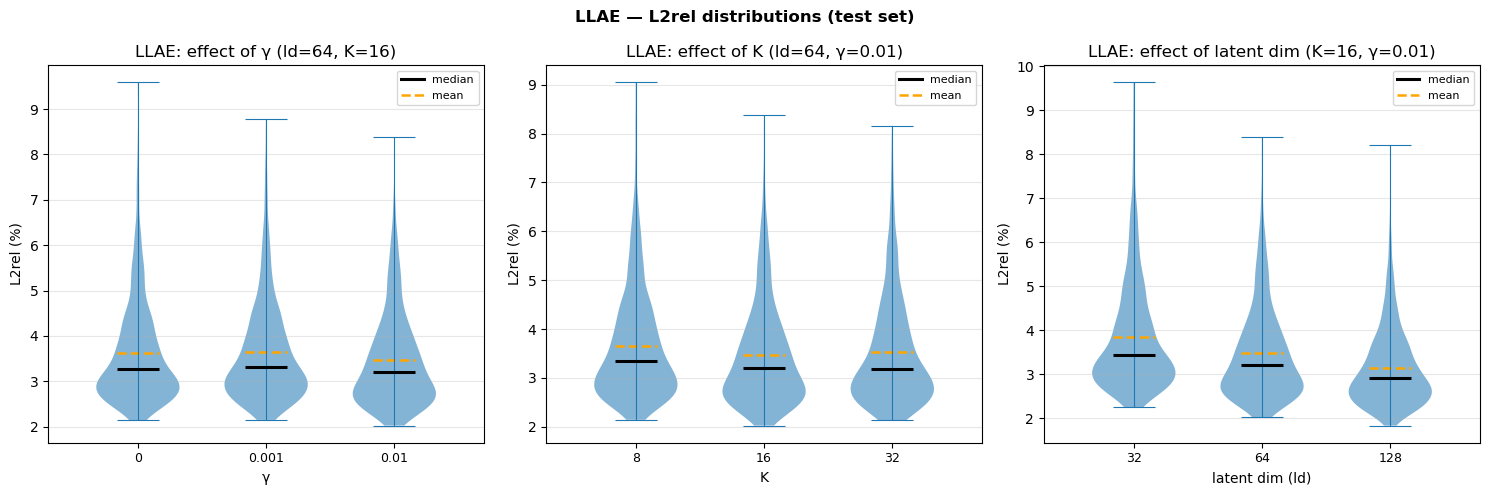

In [12]:
# LLAE — Family plots: gamma (vary), K (vary), ld (vary)
rows_gamma = _select_rows('gamma', {'ld': 64, 'K': 16})
rows_K     = _select_rows('K',     {'ld': 64, 'gamma': 0.01})
rows_ld    = _select_rows('ld',    {'K': 16,  'gamma': 0.01})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

_plot_family(axes[0], rows_gamma, 'gamma', 'γ',               'LLAE: effect of γ (ld=64, K=16)',          results)
_plot_family(axes[1], rows_K,     'K',     'K',               'LLAE: effect of K (ld=64, γ=0.01)',        results)
_plot_family(axes[2], rows_ld,    'ld',    'latent dim (ld)', 'LLAE: effect of latent dim (K=16, γ=0.01)', results)

fig.suptitle('LLAE — L2rel distributions (test set)', fontweight='bold')
fig.tight_layout()
plt.show()

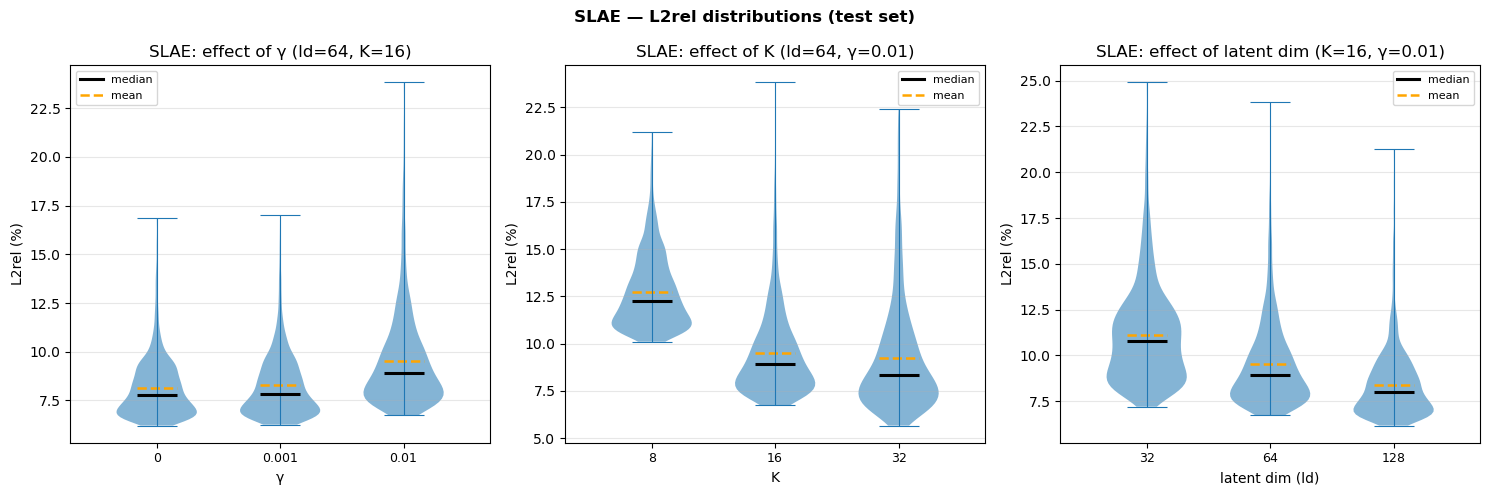

In [13]:
pat_slae = re.compile(r'^slae_ld(?P<ld>\d+)_K(?P<K>\d+)_g(?P<g>[0-9.]+)(?P<suffix>.*)$')

slae_rows = []
for name, l2 in results.items():
    m = pat_slae.match(name)
    if not m:
        continue
    suffix = m.group('suffix') or ''
    if suffix.endswith('_ll'):
        continue
    slae_rows.append({
        'name'  : name,
        'ld'    : int(m.group('ld')),
        'K'     : int(m.group('K')),
        'gamma' : float(m.group('g')),
        'suffix': suffix,
    })

def _select_slae_rows(var_name, fixed):
    rows = [r for r in slae_rows if all(r[k] == v for k, v in fixed.items())]
    return sorted(rows, key=lambda r: (r[var_name], r['suffix'], r['name']))

rows_gamma_s = _select_slae_rows('gamma', {'ld': 64, 'K': 16})
rows_K_s     = _select_slae_rows('K',     {'ld': 64, 'gamma': 0.01})
rows_ld_s    = _select_slae_rows('ld',    {'K': 16,  'gamma': 0.01})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

_plot_family(axes[0], rows_gamma_s, 'gamma', 'γ',               'SLAE: effect of γ (ld=64, K=16)',           results)
_plot_family(axes[1], rows_K_s,     'K',     'K',               'SLAE: effect of K (ld=64, γ=0.01)',         results)
_plot_family(axes[2], rows_ld_s,    'ld',    'latent dim (ld)', 'SLAE: effect of latent dim (K=16, γ=0.01)', results)

fig.suptitle('SLAE — L2rel distributions (test set)', fontweight='bold')
fig.tight_layout()
plt.show()

## 6.1 SLAE — L2rel in Laplace domain (per frequency)

In [ ]:
def eval_slae_per_freq(ckpt_path: str, idx_list: list, device='cpu') -> np.ndarray:
    """Returns (n_samples, K) array: L2rel (%) in Laplace domain at each frequency k."""
    ckpt      = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg_model = ckpt['hyper_parameters']['cfg']['model']
    s_list_np = ckpt['s_list']
    K         = len(s_list_np)
    dt        = float(ckpt.get('dt', DT))

    from laplace_surrogate.models.slae import SLAE
    model = SLAE(N=N, latent_dim=ckpt['latent_dim'],
                 beta=cfg_model.get('beta', 0.01),
                 freq_L=cfg_model.get('freq_L', 8))
    model.load_state_dict(_strip_model_prefix(ckpt['state_dict']))
    model.eval().to(device)

    s_tensor   = torch.tensor(s_list_np, dtype=torch.complex128)
    lap_mean_t = torch.tensor(ckpt['lap_mean'], dtype=torch.float32, device=device)
    lap_std_t  = torch.tensor(ckpt['lap_std'],  dtype=torch.float32, device=device)
    fr_t       = torch.tensor(np.arange(K, dtype=np.float32) / max(K - 1, 1), device=device)

    l2rel_per_sample = []
    with torch.no_grad():
        for idx in tqdm(idx_list, desc=os.path.basename(ckpt_path), leave=False):
            U_phys = load_u(idx)
            Nt     = U_phys.shape[0]

            u_flat   = torch.tensor(U_phys.reshape(Nt, N * N).T, dtype=torch.float64)
            U_lap    = laplace_forward_tik(u_flat, s_tensor, dt, 'trap')
            U_lap_np = U_lap.numpy().reshape(N, N, K)
            del u_flat, U_lap

            u_batch  = np.stack([np.stack([U_lap_np[:, :, k].real,
                                            U_lap_np[:, :, k].imag], axis=0)
                                  for k in range(K)]).astype(np.float32)
            u_b_norm = (torch.tensor(u_batch, device=device) - lap_mean_t) / lap_std_t
            u_rec_norm, _ = model(u_b_norm, fr_t)
            del u_b_norm
            u_rec_np = (u_rec_norm * lap_std_t + lap_mean_t).cpu().numpy()
            del u_rec_norm

            l2k = np.zeros(K)
            for k in range(K):
                U_k     = U_lap_np[:, :, k]
                U_rec_k = u_rec_np[k, 0] + 1j * u_rec_np[k, 1]
                denom   = np.linalg.norm(U_k)
                if denom >= 1e-12:
                    l2k[k] = np.linalg.norm(U_rec_k - U_k) / denom * 100.0
            del U_lap_np, u_batch, u_rec_np
            l2rel_per_sample.append(l2k)

    model.cpu(); del model
    if device == 'cuda': torch.cuda.empty_cache()
    gc.collect()
    return np.stack(l2rel_per_sample)   # (n_samples, K)


N_FREQ_EVAL   = 200
freq_eval_idx = test_idx[:N_FREQ_EVAL]

slae_ckpts = sorted([p for p in glob.glob(os.path.join(CKPT_DIR, '*.ckpt'))
                     if os.path.basename(p).startswith('slae')])

freq_results = {}   # name → (n_samples, K)
for ckpt_path in slae_ckpts:
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    print(f'[per-freq] {name}')
    freq_results[name] = eval_slae_per_freq(ckpt_path, freq_eval_idx, device=device)

print('Done.')

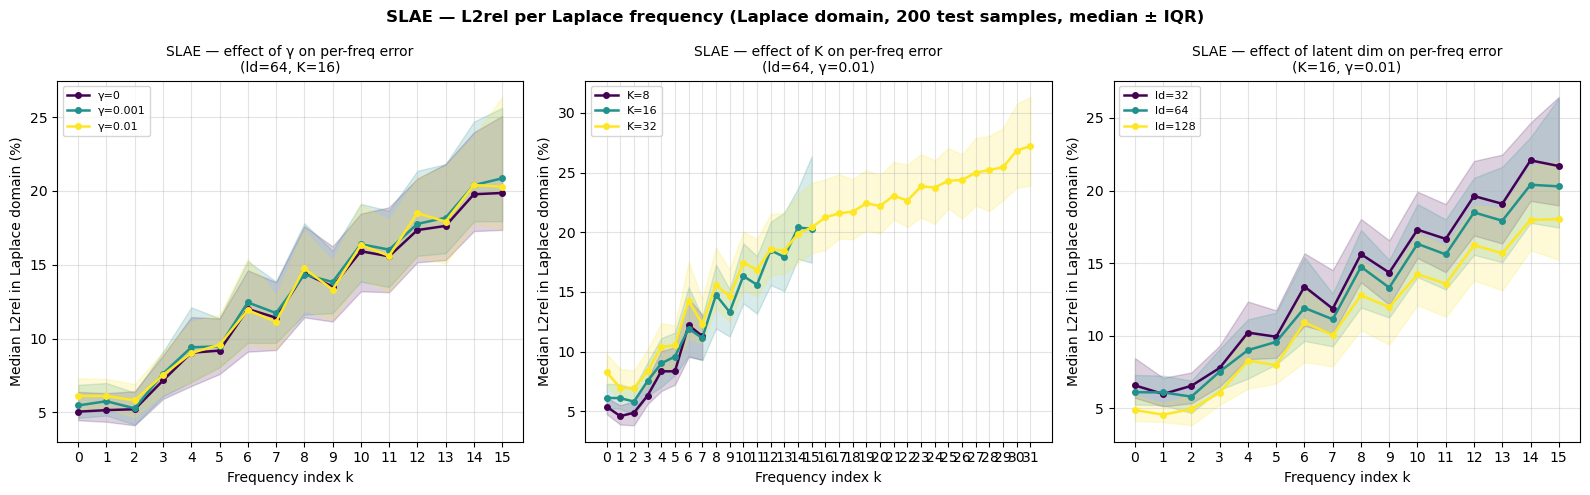

In [15]:
def _plot_freq_family(ax, rows, var_name, xlabel, title, freq_res):
    """
    One line per checkpoint in `rows`, varying `var_name`.
    x-axis = frequency index k, y-axis = median L2rel in Laplace domain.
    """
    cmap   = plt.cm.viridis
    values = sorted(set(r[var_name] for r in rows))
    norm   = plt.Normalize(vmin=0, vmax=max(len(values) - 1, 1))

    for i, val in enumerate(values):
        matching = [r for r in rows if r[var_name] == val]
        if not matching:
            continue
        name = matching[0]['name']
        if name not in freq_res:
            continue
        mat     = freq_res[name]          # (n_samples, K)
        K       = mat.shape[1]
        ks      = np.arange(K)
        medians = np.median(mat, axis=0)
        p25     = np.percentile(mat, 25, axis=0)
        p75     = np.percentile(mat, 75, axis=0)
        color   = cmap(norm(i))
        label   = f'{xlabel}={_fmt_label(val)}'
        ax.fill_between(ks, p25, p75, alpha=0.18, color=color)
        ax.plot(ks, medians, marker='o', markersize=4, linewidth=1.8,
                color=color, label=label)

    ax.set_xticks(np.arange(max(freq_res[r['name']].shape[1]
                                for r in rows if r['name'] in freq_res)))
    ax.set_xlabel('Frequency index k')
    ax.set_ylabel('Median L2rel in Laplace domain (%)')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.35)


rows_gamma_sf = _select_slae_rows('gamma', {'ld': 64, 'K': 16})
rows_K_sf     = _select_slae_rows('K',     {'ld': 64, 'gamma': 0.01})
rows_ld_sf    = _select_slae_rows('ld',    {'K': 16,  'gamma': 0.01})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

_plot_freq_family(axes[0], rows_gamma_sf, 'gamma', 'γ',
                  'SLAE — effect of γ on per-freq error\n(ld=64, K=16)', freq_results)
_plot_freq_family(axes[1], rows_K_sf,     'K',     'K',
                  'SLAE — effect of K on per-freq error\n(ld=64, γ=0.01)', freq_results)
_plot_freq_family(axes[2], rows_ld_sf,    'ld',    'ld',
                  'SLAE — effect of latent dim on per-freq error\n(K=16, γ=0.01)', freq_results)

fig.suptitle(f'SLAE — L2rel per Laplace frequency (Laplace domain, {N_FREQ_EVAL} test samples, median ± IQR)',
             fontweight='bold')
fig.tight_layout()
plt.show()

## 7. Inference benchmark (scientific)

**Latency** (bs=1, 200 runs, CUDA Events) — time to process one simulation.  
**Throughput** (max bs, 10 runs) — max samples/s using the full GPU.

Timing with `torch.cuda.Event` (μs precision, no Python overhead).  
Max batch size derived from measured peak memory at bs=1 (no binary search).

In [16]:
import time

N_BENCH      = 200   # samples pre-loaded in RAM — enough to fill the GPU pipeline
N_WARMUP_LAT = 10    # latency warmup
N_RUNS_LAT   = 50    # latency timed runs  (50 is standard for ML papers)
N_WARMUP_THR = 2     # throughput warmup
N_RUNS_THR   = 5     # throughput timed runs

bench = {}

if device == 'cuda':
    torch.cuda.empty_cache()
gc.collect()

# Pre-load benchmark data into RAM (avoids disk I/O during timing)
print(f'Pre-loading {N_BENCH} samples ...')
_bench_raw = np.stack([load_u(test_idx[i]) for i in range(N_BENCH)])   # (N_BENCH, Nt, N, N)
print(f'  {_bench_raw.nbytes / 1024**2:.0f} MB in RAM')
if device == 'cuda':
    free_gb = torch.cuda.mem_get_info()[0] / 1024**3
    print(f'  Free GPU: {free_gb:.1f} GB / {torch.cuda.mem_get_info()[1]/1024**3:.1f} GB')


# -- Timing primitives --------------------------------------------------------

def _time_gpu(fn, n_warmup, n_runs):
    """CUDA Event timing — returns array of ms per call."""
    for _ in range(n_warmup):
        fn()
    torch.cuda.synchronize()
    ev_s = torch.cuda.Event(enable_timing=True)
    ev_e = torch.cuda.Event(enable_timing=True)
    ms = []
    for _ in range(n_runs):
        ev_s.record(); fn(); ev_e.record()
        torch.cuda.synchronize()
        ms.append(ev_s.elapsed_time(ev_e))
    return np.array(ms)


def _peak_mb(peak_fn):
    """Peak GPU memory for one bs=1 forward pass."""
    if device != 'cuda': return 0.0
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    base = torch.cuda.memory_allocated()
    peak_fn()
    torch.cuda.synchronize()
    mb = (torch.cuda.max_memory_allocated() - base) / 1024**2
    torch.cuda.empty_cache()
    return mb


def _max_bs(peak_mb, safety=0.75):
    if device != 'cuda': return 64
    free_mb = torch.cuda.mem_get_info()[0] / 1024**2
    return max(1, int(free_mb * safety / peak_mb))


# -- Architecture pipelines (use pre-loaded _bench_raw) ----------------------

def _llae_pipeline(model, Nt):
    # Single sample on GPU for latency
    x1 = torch.tensor((_bench_raw[0] - U_mean) / U_std,
                       dtype=torch.float32, device=device)[None]

    def peak_fn():
        with torch.no_grad(): model(x1)

    def lat_fn():
        with torch.no_grad(): model(x1)

    def make_thr(bs):
        # Normalise the N_BENCH samples to float32 once
        data = torch.tensor((_bench_raw - U_mean) / U_std,
                             dtype=torch.float32)  # CPU, transferred batch by batch
        n = len(data)
        def run():
            for start in range(0, n, bs):
                U_t = data[start:start+bs].to(device)
                with torch.no_grad(): model(U_t)
                del U_t
        return run

    return peak_fn, lat_fn, make_thr


def _slae_pipeline(model, K, Nt, s_t, lm, ls, fr, dt):
    # Pre-process sample 0 on GPU for latency
    u1 = torch.tensor(_bench_raw[0].reshape(Nt, N*N).T,
                       dtype=torch.float32, device=device)
    Ul1 = laplace_forward_tik(u1, s_t, dt, 'trap'); del u1
    u1_ae = ((torch.stack([Ul1.real.reshape(N,N,K).permute(2,0,1),
                            Ul1.imag.reshape(N,N,K).permute(2,0,1)], dim=1) - lm) / ls)
    del Ul1                                                        # (K, 2, N, N)

    def peak_fn():
        with torch.no_grad(): out, _ = model(u1_ae, fr)
        rc = torch.complex(out[:,0].reshape(N*N, K), out[:,1].reshape(N*N, K))
        laplace_inverse_tik(rc, s_t, dt, Nt, alpha_t=ALPHA_T_SLAE, lam=LAM_SLAE)
        del out, rc

    def lat_fn():
        with torch.no_grad(): out, _ = model(u1_ae, fr)
        rc = torch.complex(out[:,0].reshape(N*N, K), out[:,1].reshape(N*N, K))
        laplace_inverse_tik(rc, s_t, dt, Nt, alpha_t=ALPHA_T_SLAE, lam=LAM_SLAE)
        del out, rc

    def make_thr(bs):
        # Pre-compute Laplace of all N_BENCH samples on CPU, keep as float32
        n = len(_bench_raw)
        lap_data = []
        for i in range(n):
            u = torch.tensor(_bench_raw[i].reshape(Nt, N*N).T,
                              dtype=torch.float32, device=device)
            Ul = laplace_forward_tik(u, s_t, dt, 'trap')
            lap_data.append(torch.stack([Ul.real.reshape(N,N,K).permute(2,0,1),
                                         Ul.imag.reshape(N,N,K).permute(2,0,1)], dim=1)
                             .cpu())   # (K, 2, N, N) on CPU
            del u, Ul
        lap_data = torch.stack(lap_data)  # (N_BENCH, K, 2, N, N) CPU

        def run():
            for start in range(0, n, bs):
                chunk = lap_data[start:start+bs].to(device)   # (B, K, 2, N, N)
                B = chunk.shape[0]
                u_norm = ((chunk - lm) / ls).reshape(B*K, 2, N, N); del chunk
                with torch.no_grad(): out, _ = model(u_norm, fr.repeat(B)); del u_norm
                rec = out.reshape(B,K,2,N,N) * ls + lm; del out
                rc  = torch.complex(rec[:,:,0].permute(0,2,3,1).reshape(B*N*N,K),
                                    rec[:,:,1].permute(0,2,3,1).reshape(B*N*N,K)); del rec
                laplace_inverse_tik(rc, s_t, dt, Nt,
                                    alpha_t=ALPHA_T_SLAE, lam=LAM_SLAE); del rc
        return run

    return peak_fn, lat_fn, make_thr


# -- Main loop ----------------------------------------------------------------
for ckpt_path in tqdm(sorted(glob.glob(os.path.join(CKPT_DIR, '*.ckpt'))),
                      desc='benchmarking'):
    name       = os.path.splitext(os.path.basename(ckpt_path))[0]
    model_type = 'llae' if name.startswith('llae') else 'slae'
    try:
        ckpt     = torch.load(ckpt_path, map_location=device, weights_only=False)
        cfg      = ckpt['hyper_parameters']['cfg']['model']
        Nt_model = cfg.get('Nt', 150)

        if model_type == 'llae':
            from laplace_surrogate.models.llae import LLAE
            model = LLAE(
                N=ckpt['N'], Nt=Nt_model, latent_dim=ckpt['latent_dim'],
                K=cfg['K'], dt=float(ckpt.get('dt', DT)),
                beta=cfg.get('beta',0.01), beta_latent=cfg.get('beta_latent',0.1),
                gamma_init=cfg.get('gamma_init',0.01), time_L=cfg.get('time_L',8),
                learnable_laplace=cfg.get('learnable_laplace',False),
                alpha_t=cfg.get('alpha_t',0.007), lam=cfg.get('lam',3e-5),
            )
            model.load_state_dict(_strip_model_prefix(ckpt['state_dict']))
            model.eval().to(device)
            peak_fn, lat_fn, make_thr = _llae_pipeline(model, Nt_model)

        else:
            from laplace_surrogate.models.slae import SLAE
            K = len(ckpt['s_list'])
            model = SLAE(N=N, latent_dim=ckpt['latent_dim'],
                         beta=cfg.get('beta',0.01), freq_L=cfg.get('freq_L',8))
            model.load_state_dict(_strip_model_prefix(ckpt['state_dict']))
            model.eval().to(device)
            s_t = torch.tensor(ckpt['s_list'], dtype=torch.complex64, device=device)
            lm  = torch.tensor(ckpt['lap_mean'], dtype=torch.float32, device=device)
            ls  = torch.tensor(ckpt['lap_std'],  dtype=torch.float32, device=device)
            fr  = torch.tensor(np.arange(K,dtype=np.float32)/max(K-1,1), device=device)
            peak_fn, lat_fn, make_thr = _slae_pipeline(
                model, K, Nt_model, s_t, lm, ls, fr, float(ckpt.get('dt', DT)))

        pmb    = _peak_mb(peak_fn)
        lat_ms = _time_gpu(lat_fn, N_WARMUP_LAT, N_RUNS_LAT)
        bs     = _max_bs(pmb)
        thr_ms = _time_gpu(make_thr(bs), N_WARMUP_THR, N_RUNS_THR)
        tput   = N_BENCH / (np.median(thr_ms) * 1e-3)

        bench[name] = dict(lat_med=np.median(lat_ms), lat_std=np.std(lat_ms),
                           tput=tput, bs=bs, peak_mb=pmb)
        print(f'{name:<40}  lat={np.median(lat_ms):6.1f}+/-{np.std(lat_ms):.1f} ms  '
              f'tput={tput:6.0f} s/s  bs={bs}  peak={pmb:.0f} MB')

    except Exception as e:
        print(f'{name}  ERROR: {e}')
    finally:
        for nm in ['model', 's_t', 'lm', 'ls', 'fr']:
            try: exec(f'{nm}.cpu()')
            except: pass
            try: exec(f'del {nm}')
            except: pass
        if device == 'cuda': torch.cuda.empty_cache()
        gc.collect()

print('\nDone.')

Pre-loading 200 samples ...
  1875 MB in RAM
  Free GPU: 23.1 GB / 23.5 GB


benchmarking:   0%|          | 0/14 [00:00<?, ?it/s]

llae_ld128_K16_g0.01                      lat=  19.0+/-0.8 ms  tput=    56 s/s  bs=32  peak=525 MB
llae_ld32_K16_g0.01                       lat=  19.0+/-1.1 ms  tput=    56 s/s  bs=32  peak=525 MB
llae_ld64_K16_g0.0                        lat=  19.4+/-1.3 ms  tput=    54 s/s  bs=32  peak=525 MB
llae_ld64_K16_g0.001                      lat=  19.7+/-1.3 ms  tput=    53 s/s  bs=32  peak=525 MB
llae_ld64_K16_g0.01                       lat=  20.0+/-2.9 ms  tput=    52 s/s  bs=32  peak=525 MB
llae_ld64_K32_g0.01                       lat=  20.0+/-1.7 ms  tput=    52 s/s  bs=32  peak=525 MB
llae_ld64_K8_g0.01                        lat=  20.1+/-1.9 ms  tput=    52 s/s  bs=32  peak=525 MB
slae_ld128_K16_g0.01                      lat=   8.1+/-0.1 ms  tput=   133 s/s  bs=156  peak=112 MB
slae_ld32_K16_g0.01                       lat=   8.0+/-0.1 ms  tput=   134 s/s  bs=156  peak=112 MB
slae_ld64_K16_g0.0                        lat=   8.0+/-0.1 ms  tput=   134 s/s  bs=156  peak=112 MB
slae_ld

Checkpoint                                type   lat med (ms)   lat std  tput (s/s)     bs   peak MB
----------------------------------------------------------------------------------------------------
slae_ld64_K8_g0.01                        slae           5.5      0.2         224    314       56
slae_ld32_K16_g0.01                       slae           8.0      0.1         134    156      112
slae_ld64_K16_g0.001                      slae           8.0      0.1         133    156      112
slae_ld64_K16_g0.0                        slae           8.0      0.1         134    156      112
slae_ld128_K16_g0.01                      slae           8.1      0.1         133    156      112
slae_ld64_K16_g0.01                       slae           8.7      0.1         132    156      112
slae_ld64_K32_g0.01                       slae          13.9      0.4          74     77      224
llae_ld32_K16_g0.01                       llae          19.0      1.1          56     32      525
llae_ld128_K16

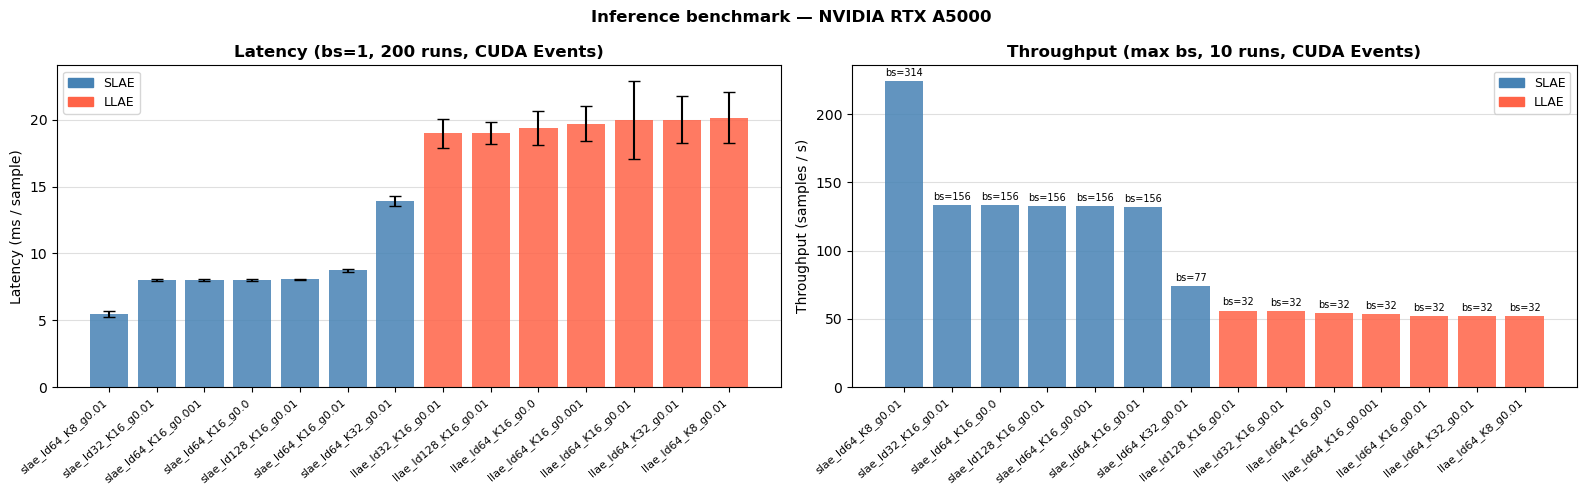

In [17]:
# ── Summary table ────────────────────────────────────────────────────────
print(f"{'Checkpoint':<40}  {'type':^5}  {'lat med (ms)':>12}  {'lat std':>8}  {'tput (s/s)':>10}  {'bs':>5}  {'peak MB':>8}")
print('-' * 100)
for n in sorted(bench, key=lambda n: bench[n]['lat_med']):
    b = bench[n]
    mt = 'llae' if n.startswith('llae') else 'slae'
    print(f"{n:<40}  {mt:^5}  {b['lat_med']:>11.1f}  {b['lat_std']:>7.1f}  "
          f"{b['tput']:>10.0f}  {b['bs']:>5}  {b['peak_mb']:>7.0f}")

# ── Two-panel plot ────────────────────────────────────────────────────────
names_s = sorted(bench, key=lambda n: bench[n]['lat_med'])
col = [colors['llae' if n.startswith('llae') else 'slae'] for n in names_s]
x   = np.arange(len(names_s))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Latency
lats = [bench[n]['lat_med'] for n in names_s]
stds = [bench[n]['lat_std']  for n in names_s]
ax1.bar(x, lats, color=col, alpha=0.85, zorder=2)
ax1.errorbar(x, lats, yerr=stds, fmt='none', color='black',
             capsize=4, linewidth=1.5, zorder=3)
ax1.set_xticks(x); ax1.set_xticklabels(names_s, rotation=40, ha='right', fontsize=8)
ax1.set_ylabel('Latency (ms / sample)')
ax1.set_title('Latency (bs=1, 200 runs, CUDA Events)', fontweight='bold')
ax1.grid(axis='y', alpha=0.4, zorder=0)

# Throughput
names_t = sorted(bench, key=lambda n: bench[n]['tput'], reverse=True)
col_t   = [colors['llae' if n.startswith('llae') else 'slae'] for n in names_t]
x2      = np.arange(len(names_t))
tputs   = [bench[n]['tput'] for n in names_t]

ax2.bar(x2, tputs, color=col_t, alpha=0.85, zorder=2)
for xi, n in zip(x2, names_t):
    ax2.text(xi, bench[n]['tput'] + max(tputs)*0.01,
             f"bs={bench[n]['bs']}", ha='center', va='bottom', fontsize=7)
ax2.set_xticks(x2); ax2.set_xticklabels(names_t, rotation=40, ha='right', fontsize=8)
ax2.set_ylabel('Throughput (samples / s)')
ax2.set_title('Throughput (max bs, 10 runs, CUDA Events)', fontweight='bold')
ax2.grid(axis='y', alpha=0.4, zorder=0)

from matplotlib.patches import Patch
for ax in (ax1, ax2):
    ax.legend(handles=[Patch(color='steelblue', label='SLAE'),
                        Patch(color='tomato',    label='LLAE')], fontsize=9)

gpu_name = torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'
fig.suptitle(f'Inference benchmark — {gpu_name}', fontweight='bold')
fig.tight_layout()
plt.show()